In [1]:
# --- CELL 1: SETUP ---
import os
import json
from typing import TypedDict, Annotated, Union, Literal
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Set your API Key (Replace with your own or use an .env file)
# os.environ["OPENAI_API_KEY"] = "your-key-here"
os.environ["GOOGLE_API_KEY"] = "your-key-here"

print("✅ Setup Complete")

✅ Setup Complete


In [2]:
# --- CELL 2: THE SHARED CLIPBOARD (STATE) ---
class SentinelState(TypedDict):
    task: str
    thought_process: list[str]
    next_action: str
    tool_input: str
    observation: str
    final_answer: str

In [3]:
# --- CELL 3: THE TOOLS (MOCK EXTERNAL SYSTEMS) ---

def search_tool(query: str):
    """Simulates a web search for market news."""
    if "nvidia" in query.lower():
        return "NVIDIA stock price is $900. Previous close was $850."
    return "No recent news found for this query."

def math_tool(expression: str):
    """Simulates a calculator for financial ratios."""
    # Simulating a calculation: (900 - 850) / 850 * 100
    if "900" in expression and "850" in expression:
        return "5.88% increase"
    return "Error in calculation"

In [4]:
# --- CELL 4: THE ReAct WORKER (NODE) ---

def reasoning_node(state: SentinelState):
    """The 'Brain' deciding what to do next."""
    print("🧠 Brain: Thinking about the next step...")

    # Logic to simulate an LLM's thought process
    if not state.get("observation"):
        thought = "I need to find the current and previous price of NVIDIA to calculate growth."
        return {
            "thought_process": state.get("thought_process", []) + [thought],
            "next_action": "search",
            "tool_input": "NVIDIA stock price news"
        }
    elif "NVIDIA stock price is" in state["observation"] and "final_answer" not in state:
        thought = "I have the prices ($900 and $850). Now I need to calculate the percentage change."
        return {
            "thought_process": state.get("thought_process", []) + [thought],
            "next_action": "calculate",
            "tool_input": "(900-850)/850"
        }
    else:
        return {"next_action": "finish"}

def action_executor_node(state: SentinelState):
    """The 'Hands' executing the tool call."""
    action = state["next_action"]
    tool_input = state["tool_input"]
    print(f"🛠️ Tool Executor: Performing {action} with input '{tool_input}'")

    if action == "search":
        result = search_tool(tool_input)
    elif action == "calculate":
        result = math_tool(tool_input)
    else:
        result = "Action not recognized"

    return {"observation": result}

def final_answer_node(state: SentinelState):
    print("🏁 Finalizer: Drafting final response...")
    return {"final_answer": f"NVIDIA has grown by {state['observation']} since the last close."}

In [5]:
# --- CELL 5: THE ROUTING LOGIC ---
def should_continue(state: SentinelState) -> Literal["call_tool", "finish"]:
    if state["next_action"] == "finish":
        return "finish"
    return "call_tool"

In [6]:
# --- CELL 6: THE FLOOR PLAN (GRAPH) ---
builder = StateGraph(SentinelState)

builder.add_node("reasoner", reasoning_node)
builder.add_node("executor", action_executor_node)
builder.add_node("finalizer", final_answer_node)

builder.add_edge(START, "reasoner")

# The ReAct Loop: Reasoner -> Executor -> Reasoner
builder.add_conditional_edges(
    "reasoner",
    should_continue,
    {
        "call_tool": "executor",
        "finish": "finalizer"
    }
)

builder.add_edge("executor", "reasoner") # Cycle back to think about the tool result
builder.add_edge("finalizer", END)

sentinel_react = builder.compile()

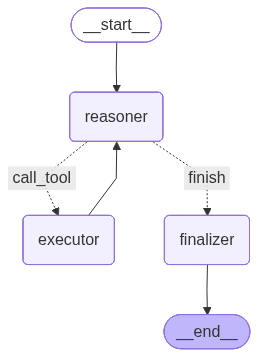

In [7]:
# --- CELL 7: VISUALIZATION ---
try:
    png_bytes = sentinel_react.get_graph().draw_mermaid_png()
    with open("sentinel_react.png", "wb") as f:
        f.write(png_bytes)
    display(Image(data=png_bytes))
except Exception as e:
    print(f"Visualization skip: {e}")

In [8]:
# --- CELL 8: RUNNING THE ReAct AGENT ---
print("\n--- STARTING ReAct EXECUTION ---")
task = "Calculate the growth percentage of NVIDIA based on recent news."
result = sentinel_react.invoke({"task": task, "thought_process": []})
print("\n" + "="*30)
print(f"FINAL RESULT: {result['final_answer']}")
print("="*30)


--- STARTING ReAct EXECUTION ---
🧠 Brain: Thinking about the next step...
🛠️ Tool Executor: Performing search with input 'NVIDIA stock price news'
🧠 Brain: Thinking about the next step...
🛠️ Tool Executor: Performing calculate with input '(900-850)/850'
🧠 Brain: Thinking about the next step...
🏁 Finalizer: Drafting final response...

FINAL RESULT: NVIDIA has grown by 5.88% increase since the last close.
